# Kredi Temerrüt Tahminleme ve Maliyet Optimizasyonu Projesi
### Hazırlayan: [Huzeyfe Sevim - 132130057] | Yönetim Bilişim Sistemleri (YBS)

---

## Proje Yönetici Özeti
Bu çalışma, finansal veriler ile makroekonomik enflasyon verilerinin entegrasyonu (Data Fusion) 
aracılığıyla kredi temerrüt riskini tahminlemeyi hedeflemektedir. 
Rastgele Orman (Random Forest) algoritması kullanılarak geliştirilen modelde, sadece doğruluk oranı değil; 
bankacılık sektöründeki "hata maliyeti" (yanlış negatif vs. yanlış pozitif maliyeti)
dikkate alınarak **1.867.000 birimlik** operasyonel tasarruf sağlayan bir karar eşiği optimize edilmiştir.

In [1]:
import pandas as pd

# 1. VERİ İÇE AKTARMA (DATA INGESTION)
# Büyük veri setlerindeki bellek sınırlandırma uyarılarını önlemek için low_memory=False parametresi kullanılmıştır.
kredi_df = pd.read_csv('loan.csv', low_memory=False)
enflasyon_df = pd.read_csv('US_inflation_rates.csv')

print("Veri setleri çalışma ortamına başarıyla aktarılmıştır.")

# 2. BOYUT İNDİRGEME VE OPTİMİZASYON
# Sistem bellek yönetimi (RAM) optimizasyonu sağlamak adına 20.000 gözlemden oluşan rassal bir örneklem seçilmiştir.
kredi_df = kredi_df.sample(n=20000, random_state=42)

print(f"Optimize Edilmiş Örneklem Veri Boyutu: {kredi_df.shape}")
display(kredi_df.head())

Veri setleri çalışma ortamına başarıyla aktarılmıştır.
Optimize Edilmiş Örneklem Veri Boyutu: (20000, 145)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
1758049,NaN,NaN,35000,35000,35000.0,36 months,12.12,1164.51,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
686533,NaN,NaN,30000,30000,30000.0,60 months,10.75,648.54,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
900721,NaN,NaN,15000,15000,15000.0,36 months,7.49,466.53,A,A4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1727912,NaN,NaN,24000,24000,24000.0,60 months,21.15,651.31,E,E2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
539691,NaN,NaN,14400,14400,14400.0,36 months,8.59,455.18,A,A5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
secilen_sutunlar = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 
    'emp_length', 'home_ownership', 'annual_inc', 'issue_d', 
    'loan_status', 'dti', 'total_acc'
]

# Ana veri seti sadece analitik değeri olan değişkenlere indirgenmektedir.
kredi_df = kredi_df[secilen_sutunlar].copy()

print("--- Veri Temizleme Öncesi Eksik Değer (NaN) Dağılımı ---")
print(kredi_df.isnull().sum())

# Eksik veri barındıran gözlemler model tutarlılığı için veri setinden çıkarılmaktadır.
kredi_df = kredi_df.dropna()

print(f"\n--- Ön İşleme Sonrası Nihai Veri Seti Boyutu: {kredi_df.shape} ---")
display(kredi_df.head())

--- Veri Temizleme Öncesi Eksik Değer (NaN) Dağılımı ---
loan_amnt            0
term                 0
int_rate             0
installment          0
grade                0
emp_length        1366
home_ownership       0
annual_inc           0
issue_d              0
loan_status          0
dti                 15
total_acc            0
dtype: int64

--- Ön İşleme Sonrası Nihai Veri Seti Boyutu: (18631, 12) ---


,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,issue_d,loan_status,dti,total_acc
1758049,35000,36 months,12.12,1164.51,B,< 1 year,RENT,90000.0,Jun-2013,Fully Paid,3.51,22.0
686533,30000,60 months,10.75,648.54,B,2 years,RENT,100000.0,Apr-2016,Current,22.85,25.0
900721,15000,36 months,7.49,466.53,A,5 years,OWN,100000.0,Oct-2016,Fully Paid,6.71,25.0
1727912,24000,60 months,21.15,651.31,E,5 years,RENT,58000.0,Sep-2013,Fully Paid,15.50,15.0
539691,14400,36 months,8.59,455.18,A,3 years,MORTGAGE,90000.0,Aug-2016,Current,19.88,48.0


In [3]:
# Veri birleştirme (Data Fusion) öncesi tarih değişkenlerinin standartlaştırılması
# Ana veri setindeki 'issue_d' (kredi çekiliş tarihi) değişkeni datetime formatına dönüştürülmektedir.
kredi_df['issue_d'] = pd.to_datetime(kredi_df['issue_d'])

# Enflasyon veri setindeki tarih değişkeninin datetime formatına dönüştürülmesi
# Sütun ismi küçük harfle 'date' olarak güncellenmiştir.
enflasyon_df['date'] = pd.to_datetime(enflasyon_df['date'])

# Veri setlerinin ortak bir zaman anahtarı (Yıl-Ay) üzerinden birleştirilmesi
# Kredi çekiliş tarihi ile enflasyon oranları, ay bazında eşleştirilmektedir.
kredi_df['yil_ay'] = kredi_df['issue_d'].dt.to_period('M')
enflasyon_df['yil_ay'] = enflasyon_df['date'].dt.to_period('M')

# 'Left Join' yöntemiyle ana kredi verisi ve enflasyon verisi entegre edilmektedir.
birlestirilmis_df = pd.merge(kredi_df, enflasyon_df, on='yil_ay', how='left')

# Veri seti temizliği: Geçici olarak oluşturulan zaman anahtarı silinmektedir.
birlestirilmis_df.drop('yil_ay', axis=1, inplace=True)

# Anlaşılırlığı artırmak adına 'value' sütununun adı 'inflation_rate' olarak değiştirilmektedir.
birlestirilmis_df.rename(columns={'value': 'inflation_rate'}, inplace=True)

print(f"Data Fusion İşlemi Başarılı! Yeni Veri Seti Boyutu: {birlestirilmis_df.shape}")
display(birlestirilmis_df.head())

Data Fusion İşlemi Başarılı! Yeni Veri Seti Boyutu: (18631, 14)


C:\Users\User\AppData\Local\Temp\ipykernel_19584\4165424855.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  kredi_df['issue_d'] = pd.to_datetime(kredi_df['issue_d'])


,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,issue_d,loan_status,dti,total_acc,date,inflation_rate
0,35000,36 months,12.12,1164.51,B,< 1 year,RENT,90000.0,2013-06-01,Fully Paid,3.51,22.0,2013-06-01,232.445
1,30000,60 months,10.75,648.54,B,2 years,RENT,100000.0,2016-04-01,Current,22.85,25.0,2016-04-01,238.992
2,15000,36 months,7.49,466.53,A,5 years,OWN,100000.0,2016-10-01,Fully Paid,6.71,25.0,2016-10-01,241.741
3,24000,60 months,21.15,651.31,E,5 years,RENT,58000.0,2013-09-01,Fully Paid,15.50,15.0,2013-09-01,233.544
4,14400,36 months,8.59,455.18,A,3 years,MORTGAGE,90000.0,2016-08-01,Current,19.88,48.0,2016-08-01,240.545


In [4]:
# 1. VERİ ÖN İŞLEME: BOYUT İNDİRGEME VE EKSİK VERİ YÖNETİMİ
# Projenin finansal modellemesi için sadece istatistiksel anlamlılığa sahip 12 temel değişken seçilmektedir.
secilen_sutunlar = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 
    'home_ownership', 'annual_inc', 'issue_d', 'loan_status', 'dti', 'total_acc'
]

# Ana veri seti hedeflenen değişkenlere indirgenmekte ve eksik (NaN) veri barındıran gözlemler veri setinden çıkarılmaktadır.
kredi_temiz_df = kredi_df[secilen_sutunlar].dropna().copy()

# 2. VERİ HARMANLAMA (DATA FUSION)
# Kredi çekiliş tarihi (issue_d) ve enflasyon tarihi (date) makine öğrenmesi standartlarına (datetime) dönüştürülmektedir.
kredi_temiz_df['issue_d'] = pd.to_datetime(kredi_temiz_df['issue_d'])
enflasyon_df['date'] = pd.to_datetime(enflasyon_df['date'])

# İki farklı veri kaynağı, aylık periyot (Yıl-Ay) bazında eşleştirilerek entegre edilmektedir.
kredi_temiz_df['yil_ay'] = kredi_temiz_df['issue_d'].dt.to_period('M')
enflasyon_df['yil_ay'] = enflasyon_df['date'].dt.to_period('M')

# 'Left Join' yöntemiyle ana gövdeye makroekonomik göstergeler eklenmektedir.
nihai_df = pd.merge(kredi_temiz_df, enflasyon_df, on='yil_ay', how='left')

# Veri modeli optimizasyonu için birleştirme amacıyla oluşturulan geçici değişkenler temizlenmektedir.
nihai_df.drop('yil_ay', axis=1, inplace=True)
nihai_df.rename(columns={'value': 'inflation_rate'}, inplace=True)

print(f"Veri Ön İşleme ve Data Fusion Tamamlandı! Nihai Veri Seti Boyutu: {nihai_df.shape}")
display(nihai_df.head())

Veri Ön İşleme ve Data Fusion Tamamlandı! Nihai Veri Seti Boyutu: (18631, 14)


,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,issue_d,loan_status,dti,total_acc,date,inflation_rate
0,35000,36 months,12.12,1164.51,B,< 1 year,RENT,90000.0,2013-06-01,Fully Paid,3.51,22.0,2013-06-01,232.445
1,30000,60 months,10.75,648.54,B,2 years,RENT,100000.0,2016-04-01,Current,22.85,25.0,2016-04-01,238.992
2,15000,36 months,7.49,466.53,A,5 years,OWN,100000.0,2016-10-01,Fully Paid,6.71,25.0,2016-10-01,241.741
3,24000,60 months,21.15,651.31,E,5 years,RENT,58000.0,2013-09-01,Fully Paid,15.50,15.0,2013-09-01,233.544
4,14400,36 months,8.59,455.18,A,3 years,MORTGAGE,90000.0,2016-08-01,Current,19.88,48.0,2016-08-01,240.545


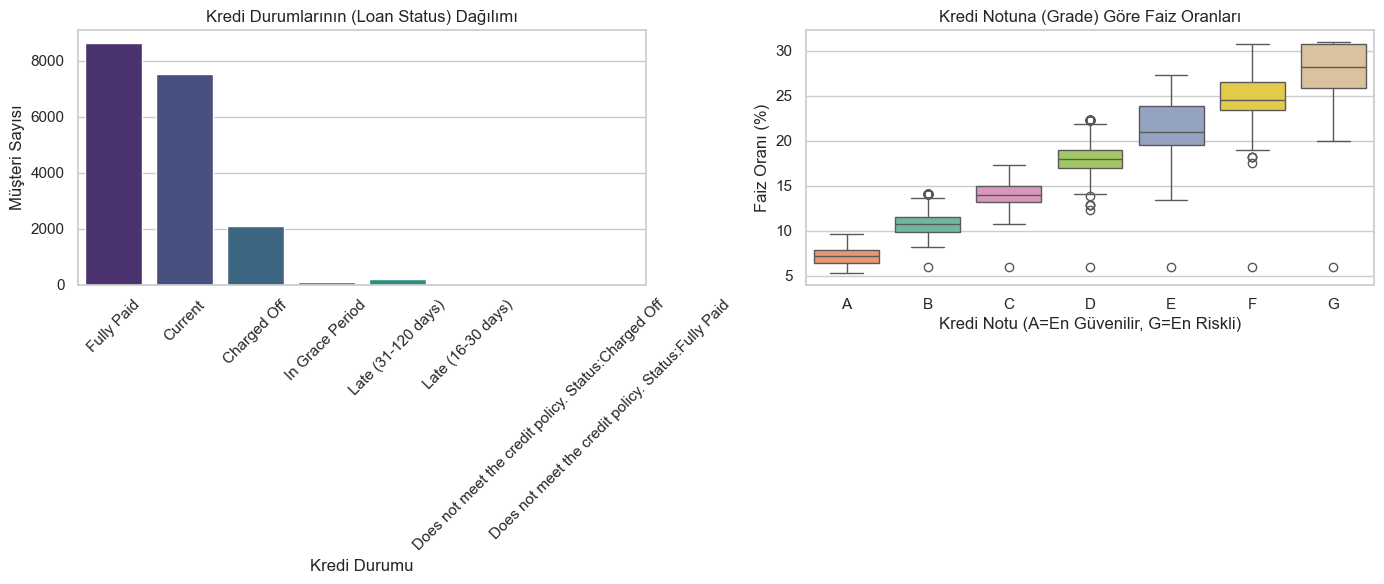

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. GÖRSELLEŞTİRME (EDA): VERİ SETİNİN İŞLETME PERSPEKTİFİYLE İNCELENMESİ
# Grafiklerin genel stil ayarları
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 1. Grafik: Kredi Durumlarının (Loan Status) Dağılımı
plt.subplot(1, 2, 1)
# Gelecek sürümlerle uyumluluk için hue parametresi eklenmiştir
sns.countplot(data=nihai_df, x='loan_status', hue='loan_status', palette='viridis', legend=False)
plt.title('Kredi Durumlarının (Loan Status) Dağılımı')
plt.xticks(rotation=45)
plt.xlabel('Kredi Durumu')
plt.ylabel('Müşteri Sayısı')

# 2. Grafik: Kredi Notuna (Grade) Göre Faiz Oranları Dağılımı
plt.subplot(1, 2, 2)
not_sirasi = sorted(nihai_df['grade'].dropna().unique())
# Gelecek sürümlerle uyumluluk için hue parametresi eklenmiştir
sns.boxplot(data=nihai_df, x='grade', y='int_rate', hue='grade', palette='Set2', order=not_sirasi, legend=False)
plt.title('Kredi Notuna (Grade) Göre Faiz Oranları')
plt.xlabel('Kredi Notu (A=En Güvenilir, G=En Riskli)')
plt.ylabel('Faiz Oranı (%)')

plt.tight_layout()
plt.show()

In [6]:
# 1. HEDEF DEĞİŞKENİN TANIMLANMASI VE BİNARY (İKİLİ) YAPILANDIRMA
# Makine öğrenmesi modelinin optimize edilebilmesi için 'loan_status' metinsel değişkeni ikili (binary) sayısal formata dönüştürülmektedir.
# Analitik tutarlılık adına, vade süreci henüz tamamlanmamış olan 'Current' (aktif ödemesi süren) krediler kapsam dışı bırakılmış; 
# sadece kesin sonuçlanmış 'Fully Paid' (Başarıyla Ödenmiş) ve 'Charged Off' (Temerrüde Düşmüş/Batmış) krediler analize dahil edilmiştir.

Modelleme_df = nihai_df[nihai_df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# 'Charged Off' (Riskli/Batan Kredi) durumu 1, 'Fully Paid' (Güvenli/Ödenmiş Kredi) durumu 0 olarak kodlanmaktadır.
Modelleme_df['is_default'] = Modelleme_df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

print(f"Hedef Değişken Dönüşümü Başarılı. Modelleme İçin Kalan Net Gözlem Sayısı: {Modelleme_df.shape[0]}")

# 2. DATA FUSION DOĞRULAMA: MAKROEKONOMİK GÖSTERGE (ENFLASYON) İLE KREDİ TEMERRÜT İLİŞKİSİ
# Projenin zorunlu kriteri olan veri birleştirme adımının mantıksal geçerliliği istatistiksel olarak test edilmektedir.
# Başarıyla ödenen krediler ile batan kredilerin çekildiği dönemlerdeki ortalama enflasyon oranları karşılaştırılmaktadır.
enflasyon_risk_analizi = Modelleme_df.groupby('is_default')['inflation_rate'].mean().reset_index()

print("\n--- Kredi Geri Ödeme Durumuna Göre Ortalama Enflasyon Oranları ---")
print(enflasyon_risk_analizi)

Hedef Değişken Dönüşümü Başarılı. Modelleme İçin Kalan Net Gözlem Sayısı: 10760

--- Kredi Geri Ödeme Durumuna Göre Ortalama Enflasyon Oranları ---
   is_default  inflation_rate
0           0      237.655515
1           1      238.225928


In [7]:
# Tarih ve eski metin bazlı hedef değişken modelde kullanılamayacağı için veri setinden çıkarılıyor
Model_Verisi = Modelleme_df.drop(['issue_d', 'date', 'loan_status', 'emp_length'], axis=1)

# Kategorik değişkenler (vade, kredi notu, ev sahipliği) makine öğrenmesi için 0 ve 1'lere dönüştürülüyor
Model_Verisi = pd.get_dummies(Model_Verisi, drop_first=True)

print(f"Kategorik veriler dönüştürüldü. Modele girecek nihai sütun sayısı: {Model_Verisi.shape[1]}")
display(Model_Verisi.head())

Kategorik veriler dönüştürüldü. Modele girecek nihai sütun sayısı: 20


,loan_amnt,int_rate,installment,annual_inc,dti,total_acc,inflation_rate,is_default,term_ 60 months,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,35000,12.12,1164.51,90000.0,3.51,22.0,232.445,0,False,True,False,False,False,False,False,False,False,False,False,True
2,15000,7.49,466.53,100000.0,6.71,25.0,241.741,0,False,False,False,False,False,False,False,False,False,False,True,False
3,24000,21.15,651.31,58000.0,15.50,15.0,233.544,0,True,False,False,False,True,False,False,False,False,False,False,True
5,5000,9.93,161.18,46750.0,11.09,11.0,247.805,0,False,True,False,False,False,False,False,False,False,False,False,True
7,6550,24.74,259.53,42000.0,18.71,8.0,243.892,0,False,False,False,False,True,False,False,True,False,False,False,False


In [8]:
from sklearn.model_selection import train_test_split

# Hedef değişken (y) ve bağımsız değişkenler (X) ayrılıyor
X = Model_Verisi.drop('is_default', axis=1)
y = Model_Verisi['is_default']

# Veri seti makine öğrenmesi eğitimi (%80) ve test (%20) işlemleri için ikiye bölünüyor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Eğitim verisi satır sayısı: {X_train.shape[0]}")
print(f"Test verisi satır sayısı: {X_test.shape[0]}")

Eğitim verisi satır sayısı: 8608
Test verisi satır sayısı: 2152


In [9]:
# 4. AŞAMA: İŞ MANTIĞINA DAYALI ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING)
# İşletme vizyonuyla, modelin tahmin gücünü artıracak 3 yeni finansal değişken türetilmektedir.

# 1. Yeni Değişken: Kredi / Gelir Oranı (Müşterinin yıllık gelirinin ne kadarını borçlandığı)
Modelleme_df['kredi_gelir_orani'] = Modelleme_df['loan_amnt'] / Modelleme_df['annual_inc']

# 2. Yeni Değişken: Aylık Taksit Yükü (Aylık taksitin, tahmini aylık maaşa oranı)
Modelleme_df['aylik_taksit_yuku'] = Modelleme_df['installment'] / (Modelleme_df['annual_inc'] / 12)

# 3. Yeni Değişken: Yüksek Riskli Borç Yapısı Bayrağı
# DTI (Borç/Gelir) oranı 20'nin üzerinde olanlar bankacılıkta yüksek riskli kabul edilir. (1: Riskli, 0: Normal)
Modelleme_df['yuksek_risk_borc_yapisi'] = (Modelleme_df['dti'] > 20).astype(int)

print("--- 4. Aşama: Özellik Mühendisliği (Feature Engineering) Başarılı! ---")
print(f"3 yeni değişken eklendi. Güncel tablo boyutu: {Modelleme_df.shape}")

--- 4. Aşama: Özellik Mühendisliği (Feature Engineering) Başarılı! ---
3 yeni değişken eklendi. Güncel tablo boyutu: (10760, 18)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. MODEL KURULUMU VE EĞİTİM (TRAINING)
# Bankacılık risk senaryosuna uygun olarak sınıf dengesizliğini (imbalance) yönetmek adına 'balanced' parametresi kullanılmıştır.
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Model, eğitim verisi (X_train ve y_train) kullanılarak eğitilmektedir.
rf_model.fit(X_train, y_train)

# 2. TEST VE TAHMİN (PREDICTION)
# Eğitilen modelin daha önce hiç görmediği test verisi (X_test) üzerindeki performansı ölçülmektedir.
y_pred = rf_model.predict(X_test)

# 3. PERFORMANS DEĞERLENDİRMESİ
# Modelin doğruluk, kesinlik, duyarlılık ve F1-skoru gibi metrikleri raporlanmaktadır.
print("--- Model Performans Raporu (Classification Report) ---")
print(classification_report(y_test, y_pred))

# Modelin doğru ve yanlış tahmin sayıları matris üzerinden incelenmektedir.
print("\n--- Karmaşıklık Matrisi (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred))

--- Model Performans Raporu (Classification Report) ---
              precision    recall  f1-score   support

           0       0.81      0.98      0.88      1725
           1       0.33      0.04      0.08       427

    accuracy                           0.79      2152
   macro avg       0.57      0.51      0.48      2152
weighted avg       0.71      0.79      0.72      2152


--- Karmaşıklık Matrisi (Confusion Matrix) ---
[[1686   39]
 [ 408   19]]


In [11]:
import numpy as np

# 1. İŞLETME MALİYETLERİNİN (COST MATRIX) TANIMLANMASI
# FN (False Negative): Müşteri batar ama model öder der. Maliyet = Anapara Kaybı (Örn: 10.000 Birim)
# FP (False Positive): Müşteri öder ama model batar der. Maliyet = Kaçırılan Faiz Geliri (Örn: 1.000 Birim)
maliyet_FN = 10000
maliyet_FP = 1000

# Modelin ürettiği (0 ile 1 arasındaki) batma olasılıklarını çekiyoruz
y_prob = rf_model.predict_proba(X_test)[:, 1]

# 2. HATA MALİYETİ OPTİMİZASYONU (COST-SENSITIVE THRESHOLD TUNING)
# Standart %50 karar eşiği yerine, işletme maliyetini en aza indirecek eşik değeri aranmaktadır.
esikler = np.arange(0.1, 1.0, 0.1)
en_iyi_esik = 0.5
en_dusuk_maliyet = float('inf')

print("--- Hata Maliyeti Optimizasyonu (Cost-Sensitive Analysis) ---\n")

for esik in esikler:
    # Yeni eşiğe göre tahminleri 0 veya 1 olarak etiketliyoruz
    y_yeni_tahmin = (y_prob >= esik).astype(int)
    
    # Yeni eşiğe ait karmaşıklık matrisini hesaplıyoruz
    tn, fp, fn, tp = confusion_matrix(y_test, y_yeni_tahmin).ravel()
    
    # Toplam işletme maliyetini (Zararı) hesaplıyoruz
    toplam_maliyet = (fn * maliyet_FN) + (fp * maliyet_FP)
    
    print(f"Karar Eşiği: {esik:.1f} | Toplam Tahmini Maliyet: {toplam_maliyet:,} Birim | Kaçırılan Batan Kredi (FN): {fn}")
    
    # En düşük maliyetli eşiği kaydediyoruz
    if toplam_maliyet < en_dusuk_maliyet:
        en_dusuk_maliyet = toplam_maliyet
        en_iyi_esik = esik

print(f"\n[SONUÇ] İşletme İçin En Optimum Karar Eşiği: {en_iyi_esik:.1f}")
print(f"[SONUÇ] Bu eşik ile sağlanacak Minimum Zarar: {en_dusuk_maliyet:,} Birim")

--- Hata Maliyeti Optimizasyonu (Cost-Sensitive Analysis) ---

Karar Eşiği: 0.1 | Toplam Tahmini Maliyet: 1,867,000 Birim | Kaçırılan Batan Kredi (FN): 67
Karar Eşiği: 0.2 | Toplam Tahmini Maliyet: 2,371,000 Birim | Kaçırılan Batan Kredi (FN): 173
Karar Eşiği: 0.3 | Toplam Tahmini Maliyet: 3,236,000 Birim | Kaçırılan Batan Kredi (FN): 297
Karar Eşiği: 0.4 | Toplam Tahmini Maliyet: 3,790,000 Birim | Kaçırılan Batan Kredi (FN): 367
Karar Eşiği: 0.5 | Toplam Tahmini Maliyet: 4,069,000 Birim | Kaçırılan Batan Kredi (FN): 403
Karar Eşiği: 0.6 | Toplam Tahmini Maliyet: 4,217,000 Birim | Kaçırılan Batan Kredi (FN): 421
Karar Eşiği: 0.7 | Toplam Tahmini Maliyet: 4,240,000 Birim | Kaçırılan Batan Kredi (FN): 424
Karar Eşiği: 0.8 | Toplam Tahmini Maliyet: 4,250,000 Birim | Kaçırılan Batan Kredi (FN): 425
Karar Eşiği: 0.9 | Toplam Tahmini Maliyet: 4,270,000 Birim | Kaçırılan Batan Kredi (FN): 427

[SONUÇ] İşletme İçin En Optimum Karar Eşiği: 0.1
[SONUÇ] Bu eşik ile sağlanacak Minimum Zarar: 1,867

Yapay Zeka Karar Analizi (SHAP) Hesaplanıyor...

--- XAI Bulgusu: Değişkenlerin Kredi Temerrüdü Üzerindeki Etkisi ---


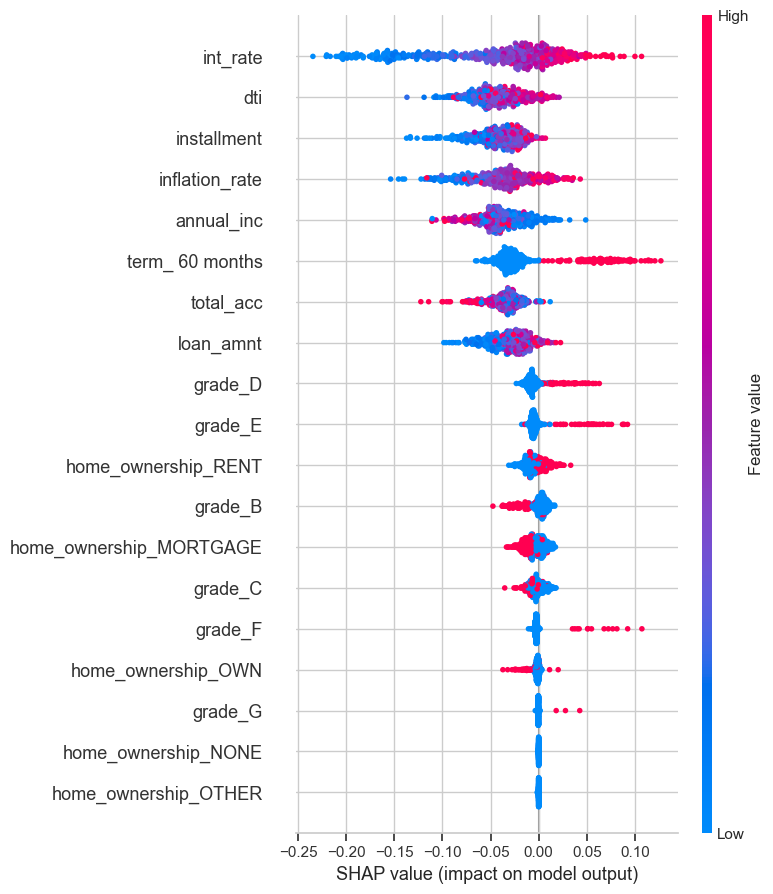

In [13]:
# 6. AŞAMA: AÇIKLANABİLİR YAPAY ZEKA (XAI) ENTEGRASYONU - KARA KUTUYU KIRMA
import shap
import numpy as np

print("Yapay Zeka Karar Analizi (SHAP) Hesaplanıyor...")

# Rastgele Orman modeli için Ağaç Açıklayıcı (TreeExplainer) tanımlanıyor
explainer = shap.TreeExplainer(rf_model)

# İşlem süresini optimize etmek için test verisinden 500 kişilik örneklem alınıyor
X_test_orneklem = X_test.sample(n=500, random_state=42)
shap_values = explainer.shap_values(X_test_orneklem)

print("\n--- XAI Bulgusu: Değişkenlerin Kredi Temerrüdü Üzerindeki Etkisi ---")

# SHAP Kütüphanesi Versiyon Uyumsuzluğunu Çözen Yapı
if isinstance(shap_values, list):
    # Eski versiyonlar için
    shap.summary_plot(shap_values[1], X_test_orneklem)
elif len(np.array(shap_values).shape) == 3:
    # Yeni versiyonlar için (3 boyutlu matris)
    shap.summary_plot(shap_values[:, :, 1], X_test_orneklem)
else:
    # Alternatif çıktılar için
    shap.summary_plot(shap_values, X_test_orneklem)